<a href="https://colab.research.google.com/github/Ravravan/ML/blob/main/bagging_learning_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
df = pd.read_csv('/content/iris (1).csv')

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df = df.iloc[:,1:]

In [7]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
encoder = LabelEncoder()

In [10]:
df['Species'] = encoder.fit_transform(df['Species'])

In [11]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df= df[df['Species'] !=0][['SepalLengthCm','PetalLengthCm','Species']]

In [13]:
df.head()

,SepalLengthCm,PetalLengthCm,Species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

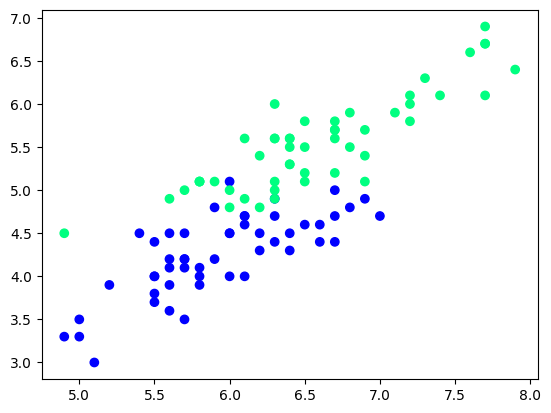

In [15]:
plt.scatter(df['SepalLengthCm'],df['PetalLengthCm'], c=df['Species'],cmap='winter')

In [16]:
#taking only 10 rows for trainig
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [17]:
df_train

,SepalLengthCm,PetalLengthCm,Species
94,5.6,4.2,1
107,7.3,6.3,2
95,5.7,4.2,1
50,7.0,4.7,1
98,5.1,3.0,1
88,5.6,4.1,1
68,6.2,4.5,1
71,6.1,4.0,1
111,6.4,5.3,2
89,5.5,4.0,1


In [18]:
df_val

,SepalLengthCm,PetalLengthCm,Species
142,5.8,5.1,2
65,6.7,4.4,1
131,7.9,6.4,2
137,6.4,5.5,2
59,5.2,3.9,1


In [19]:
df_test

,SepalLengthCm,PetalLengthCm,Species
56,6.3,4.7,1
81,5.5,3.7,1
140,6.7,5.6,2
79,5.7,3.5,1
110,6.5,5.1,2


In [20]:
X_test =df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [21]:
X_test

array([[5.8, 5.1],
       [6.7, 4.4],
       [7.9, 6.4],
       [6.4, 5.5],
       [5.2, 3.9]])

In [22]:
y_test

array([2, 1, 2, 2, 1])

# case 1-Bagging

In [23]:
#Data for Tree 1
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalLengthCm,PetalLengthCm,Species
95,5.7,4.2,1
50,7.0,4.7,1
95,5.7,4.2,1
95,5.7,4.2,1
68,6.2,4.5,1
88,5.6,4.1,1
68,6.2,4.5,1
50,7.0,4.7,1


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

In [26]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

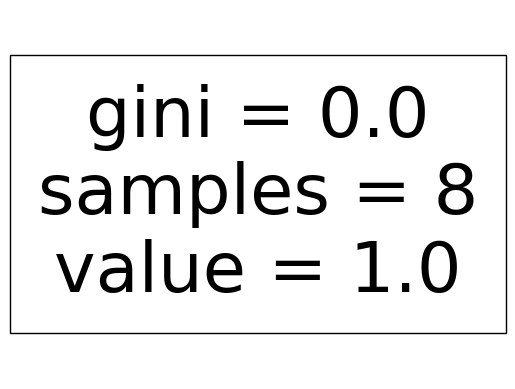

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


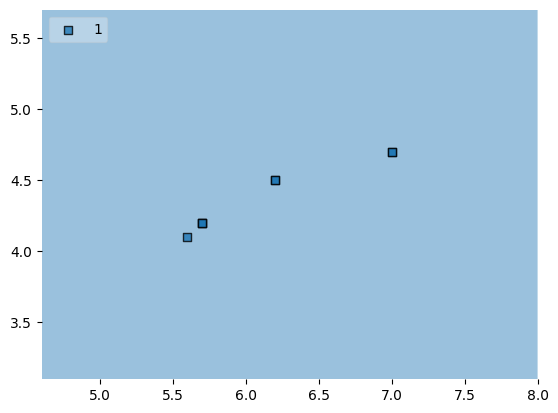

In [27]:
evaluate(dt_bag1,X,y)

In [28]:
#Data for Tree 2
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalLengthCm,PetalLengthCm,Species
50,7.0,4.7,1
95,5.7,4.2,1
107,7.3,6.3,2
111,6.4,5.3,2
111,6.4,5.3,2
98,5.1,3.0,1
89,5.5,4.0,1
98,5.1,3.0,1


In [29]:
dt_bag2 =DecisionTreeClassifier()

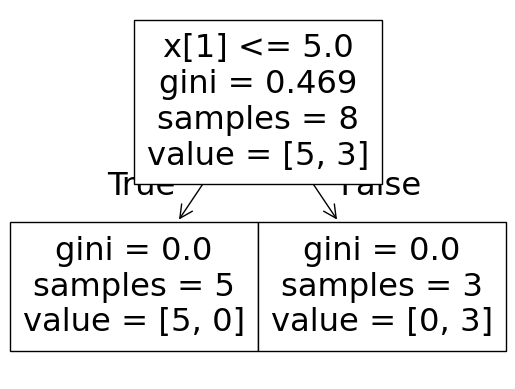

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


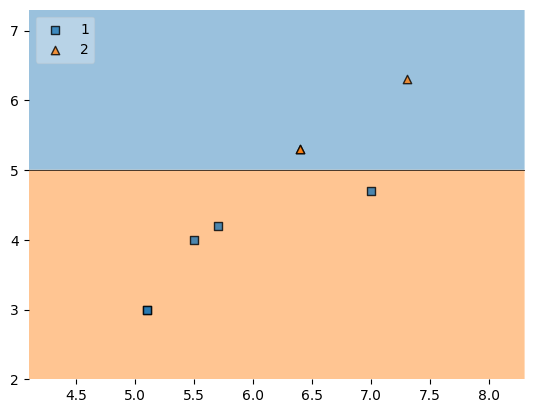

In [30]:
evaluate(dt_bag2,X,y)

In [31]:
#Data for Tree 3
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalLengthCm,PetalLengthCm,Species
71,6.1,4.0,1
68,6.2,4.5,1
94,5.6,4.2,1
88,5.6,4.1,1
50,7.0,4.7,1
111,6.4,5.3,2
94,5.6,4.2,1
68,6.2,4.5,1


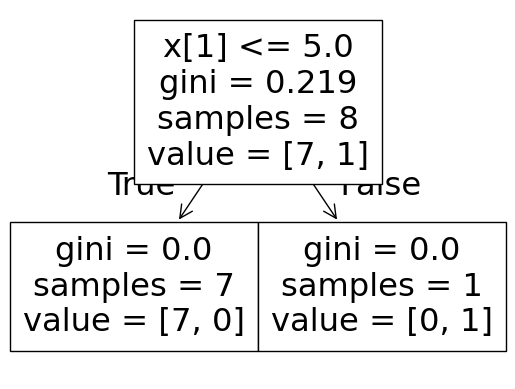

1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


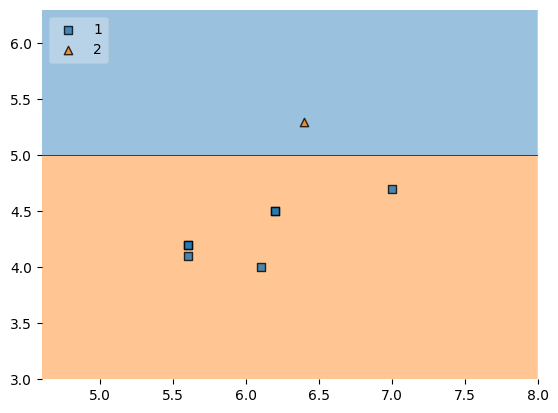

In [32]:
dt_bag3 =DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# predict


In [33]:
df_test

,SepalLengthCm,PetalLengthCm,Species
56,6.3,4.7,1
81,5.5,3.7,1
140,6.7,5.6,2
79,5.7,3.5,1
110,6.5,5.1,2


In [34]:
#prediction depends on the majority
print('predictor 1 ',dt_bag1.predict(np.array([6.1,4.0]).reshape(1,2)))
print('predictor 2 ',dt_bag2.predict(np.array([6.1,4.0]).reshape(1,2)))
print('predictor 3 ',dt_bag3.predict(np.array([6.1,4.0]).reshape(1,2)))

predictor 1  [1]
predictor 2  [1]
predictor 3  [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [35]:
print('predictor 1 ',dt_bag1.predict(np.array([7.2,6.1]).reshape(1,2)))
print('predictor 2 ',dt_bag2.predict(np.array([7.2,6.1]).reshape(1,2)))
print('predictor 3 ',dt_bag3.predict(np.array([7.2,6.1]).reshape(1,2)))

predictor 1  [1]
predictor 2  [2]
predictor 3  [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
